# Parte 2 — Análisis de Threshold con Costo-Beneficio

**Objetivo:** Encontrar el threshold óptimo de decisión considerando simultáneamente
rentabilidad financiera y restricciones de fairness.

**Por qué importa:** El modelo predice probabilidades. La decisión de usar 0.50 como
corte es arbitraria. El threshold real debería maximizar la ganancia esperada del
portfolio bajo la restricción de que el Disparate Impact Ratio sea > 0.80.

**Lo que vas a producir:** Un gráfico con 5 curvas en función del threshold y una
recomendación fundamentada con números.

---

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Cargar modelo y datos
with open('../models/champion/model.pkl', 'rb') as f:
    model = pickle.load(f)

X_test  = pd.read_parquet('../data/processed/X_test.parquet')
y_test  = pd.read_parquet('../data/processed/y_test.parquet').iloc[:, 0]
raw_test = pd.read_parquet('../data/processed/test.parquet')

y_score = model.predict_proba(X_test)[:, 1]
print(f'Score medio: {y_score.mean():.4f} | Std: {y_score.std():.4f}')

Score medio: 0.3902 | Std: 0.2092


## 2.1 Definición de Asunciones Financieras

In [6]:
# ================================================================
# PARÁMETROS POR MERCADO — DATOS ACTUALIZADOS ABRIL 2026
# ================================================================
# El threshold óptimo cambia según el mercado porque varían
# la tasa de interés, el LGD y las condiciones macroeconómicas.
# ================================================================

MERCADOS = {

    "Argentina": {
        "tasa_interes_anual": 0.80,    # TEA aproximada promedio crédito personal bancario 2026
                                       # Rango amplio: desde ~60-80% TNA en bancos públicos/privados 
                                       # con clientes de nómina hasta +200% en algunos casos. 
                                       # Referencia tope sistema ~72.56% (Comunicación B 13096/2025, dic-2025)
        "lgd": 0.68,                   # LGD estimado ligeramente superior por aumento de morosidad 
                                       # (reportes 2025-2026 muestran cartera irregular en personal ~9-10%)
        "monto_promedio": 1.0,         # Normalizado
        "moneda": "ARS",
        "fuente_tasa": "BCRA — Tasas de interés por préstamos personales + Infobae/BBVA/Nación (abr 2026)",
        "fuente_lgd":  "BCRA Informes de Estabilidad Financiera + datos de morosidad 2025-2026",
        "nota": "Alta volatilidad y dispersión de tasas. Morosidad en préstamos personales subió notablemente en 2025.",
    },

    "USA": {
        "tasa_interes_anual": 0.115,   # APR promedio personal loans ~11.4-11.6% (Federal Reserve G.19, datos 2026)
        "lgd": 0.45,                   # LGD estable en consumer ABS (Moody's historical ~35-55%)
        "monto_promedio": 1.0,
        "moneda": "USD",
        "fuente_tasa": "Federal Reserve G.19 Consumer Credit — abril 2026",
        "fuente_lgd":  "Moody's Structured Finance — US Consumer ABS studies",
        "nota": "Mercado maduro con tasas mucho más bajas y estables. Buena granularidad de datos de bureaus.",
    },

    "Brasil": {
        "tasa_interes_anual": 0.59,    # ~59.4% a.a. crédito libre a familias (Banco Central do Brasil, nov 2025)
                                       # Crédito personal no consignado sigue en zona alta (~8% mensual promedio)
        "lgd": 0.60,
        "monto_promedio": 1.0,
        "moneda": "BRL",
        "fuente_tasa": "Banco Central do Brasil — Estatísticas Monetárias e de Crédito (datos 2025-2026)",
        "fuente_lgd":  "Estimado por analogía con mercados emergentes + reportes BCB",
        "nota": "Sigue siendo uno de los mercados de crédito al consumo más caros de LATAM. Selic alta influye.",
    },

    "Colombia": {
        "tasa_interes_anual": 0.2676,  # Tasa de usura crédito de consumo y ordinario ~26.76% E.A. (abr 2026)
                                       # Interés Bancario Corriente 17.84% → Usura = 1.5 × IBC
        "lgd": 0.55,
        "monto_promedio": 1.0,
        "moneda": "COP",
        "fuente_tasa": "Superintendencia Financiera de Colombia — Resolución 0517 de 2026 (marzo 2026)",
        "fuente_lgd":  "Estimado basado en reportes Asobancaria y estudios de riesgo",
        "nota": "La regulación de tasa de usura sigue limitando el pricing máximo. Tasa subió levemente en 2026.",
    },
}

# Mercado activo para el análisis principal
# Cambiá esto para re-correr el análisis con otro mercado
MERCADO_ACTIVO = "USA"  # USA, Argentina, Brasil o Colombia

# Extraer parámetros del mercado activo
TASA_INTERES_ANUAL = MERCADOS[MERCADO_ACTIVO]["tasa_interes_anual"]
LGD                = MERCADOS[MERCADO_ACTIVO]["lgd"]
MONTO_PROMEDIO     = MERCADOS[MERCADO_ACTIVO]["monto_promedio"]

print(f"Mercado activo: {MERCADO_ACTIVO}")
print(f"  Tasa TEA aproximada:  {TASA_INTERES_ANUAL:.1%}")
print(f"  LGD:                  {LGD:.0%}")
print(f"  Fuente tasa:          {MERCADOS[MERCADO_ACTIVO]['fuente_tasa']}")
print(f"  Nota:                 {MERCADOS[MERCADO_ACTIVO]['nota']}")

Mercado activo: USA
  Tasa TEA aproximada:  11.5%
  LGD:                  45%
  Fuente tasa:          Federal Reserve G.19 Consumer Credit — abril 2026
  Nota:                 Mercado maduro con tasas mucho más bajas y estables. Buena granularidad de datos de bureaus.


## 2.2 Curvas de Threshold

In [11]:
def calcular_metricas_threshold(y_true, y_score, y_score_gender, gender,
                                 threshold, tasa=TASA_INTERES_ANUAL, lgd=LGD):
    y_pred     = (y_score >= threshold).astype(int)
    y_approved = (y_pred == 0).astype(int)  # aprobado = no predice default

    # Métricas financieras
    ganancias = []
    for aprobado, real_default in zip(y_approved, y_true):
        if aprobado:
            if real_default == 0:
                ganancias.append(MONTO_PROMEDIO * tasa)
            else:
                ganancias.append(-MONTO_PROMEDIO * lgd)
        else:
            ganancias.append(0.0)
    ganancia_total = np.sum(ganancias)

    # Fairness — Disparate Impact Ratio por género
    tasa_aprobacion_M = y_approved[gender == 'M'].mean() if (gender == 'M').sum() > 0 else np.nan
    tasa_aprobacion_F = y_approved[gender == 'F'].mean() if (gender == 'F').sum() > 0 else np.nan

    if tasa_aprobacion_M > 0 and tasa_aprobacion_F > 0:
        dir_ratio = min(tasa_aprobacion_M, tasa_aprobacion_F) / max(tasa_aprobacion_M, tasa_aprobacion_F)
        dpd = abs(tasa_aprobacion_M - tasa_aprobacion_F)
    else:
        dir_ratio, dpd = np.nan, np.nan

    return {
        'threshold':         threshold,
        'tasa_aprobacion':   y_approved.mean(),
        'mora_esperada':     y_true[y_approved == 1].mean() if y_approved.sum() > 0 else 0,
        'ganancia_total':    ganancia_total,
        'dir_genero':        dir_ratio,
        'dpd_genero':        dpd,
    }

# Extraer género del raw test
gender_arr = raw_test['CODE_GENDER'].values if 'CODE_GENDER' in raw_test.columns else np.array(['M'] * len(y_test))

# ================================================================
# ANÁLISIS DE THRESHOLD POR MERCADO
# ================================================================
# Generar curvas para cada mercado simultáneamente

thresholds = np.arange(0.15, 0.75, 0.025)
resultados_por_mercado_detalle = {}

for nombre_mercado, params in MERCADOS.items():
    tasa = params["tasa_interes_anual"]
    lgd  = params["lgd"]
    
    resultados = []
    for t in thresholds:
        m = calcular_metricas_threshold(y_test.values, y_score, y_score, gender_arr, t, 
                                       tasa=tasa, lgd=lgd)
        resultados.append(m)
    
    resultados_por_mercado_detalle[nombre_mercado] = pd.DataFrame(resultados)
    print(f"\n{'='*60}")
    print(f"MERCADO: {nombre_mercado}")
    print(f"Tasa: {tasa:.1%} | LGD: {lgd:.0%}")
    print(f"{'='*60}")
    print(resultados_por_mercado_detalle[nombre_mercado].round(4).to_string())

print("\n" + "="*60)



MERCADO: Argentina
Tasa: 80.0% | LGD: 68%
    threshold  tasa_aprobacion  mora_esperada  ganancia_total  dir_genero  dpd_genero
0       0.150           0.1262         0.0146         6043.96      0.7418      0.0357
1       0.175           0.1699         0.0153         8122.40      0.7413      0.0482
2       0.200           0.2139         0.0164        10202.72      0.7437      0.0601
3       0.225           0.2590         0.0184        12311.16      0.7433      0.0729
4       0.250           0.3064         0.0204        14506.08      0.7495      0.0839
5       0.275           0.3520         0.0226        16594.80      0.7595      0.0922
6       0.300           0.3975         0.0244        18673.24      0.7696      0.0994
7       0.325           0.4414         0.0255        20691.96      0.7830      0.1034
8       0.350           0.4820         0.0272        22522.44      0.7914      0.1082
9       0.375           0.5224         0.0292        24314.84      0.8019      0.1110
10      0.4

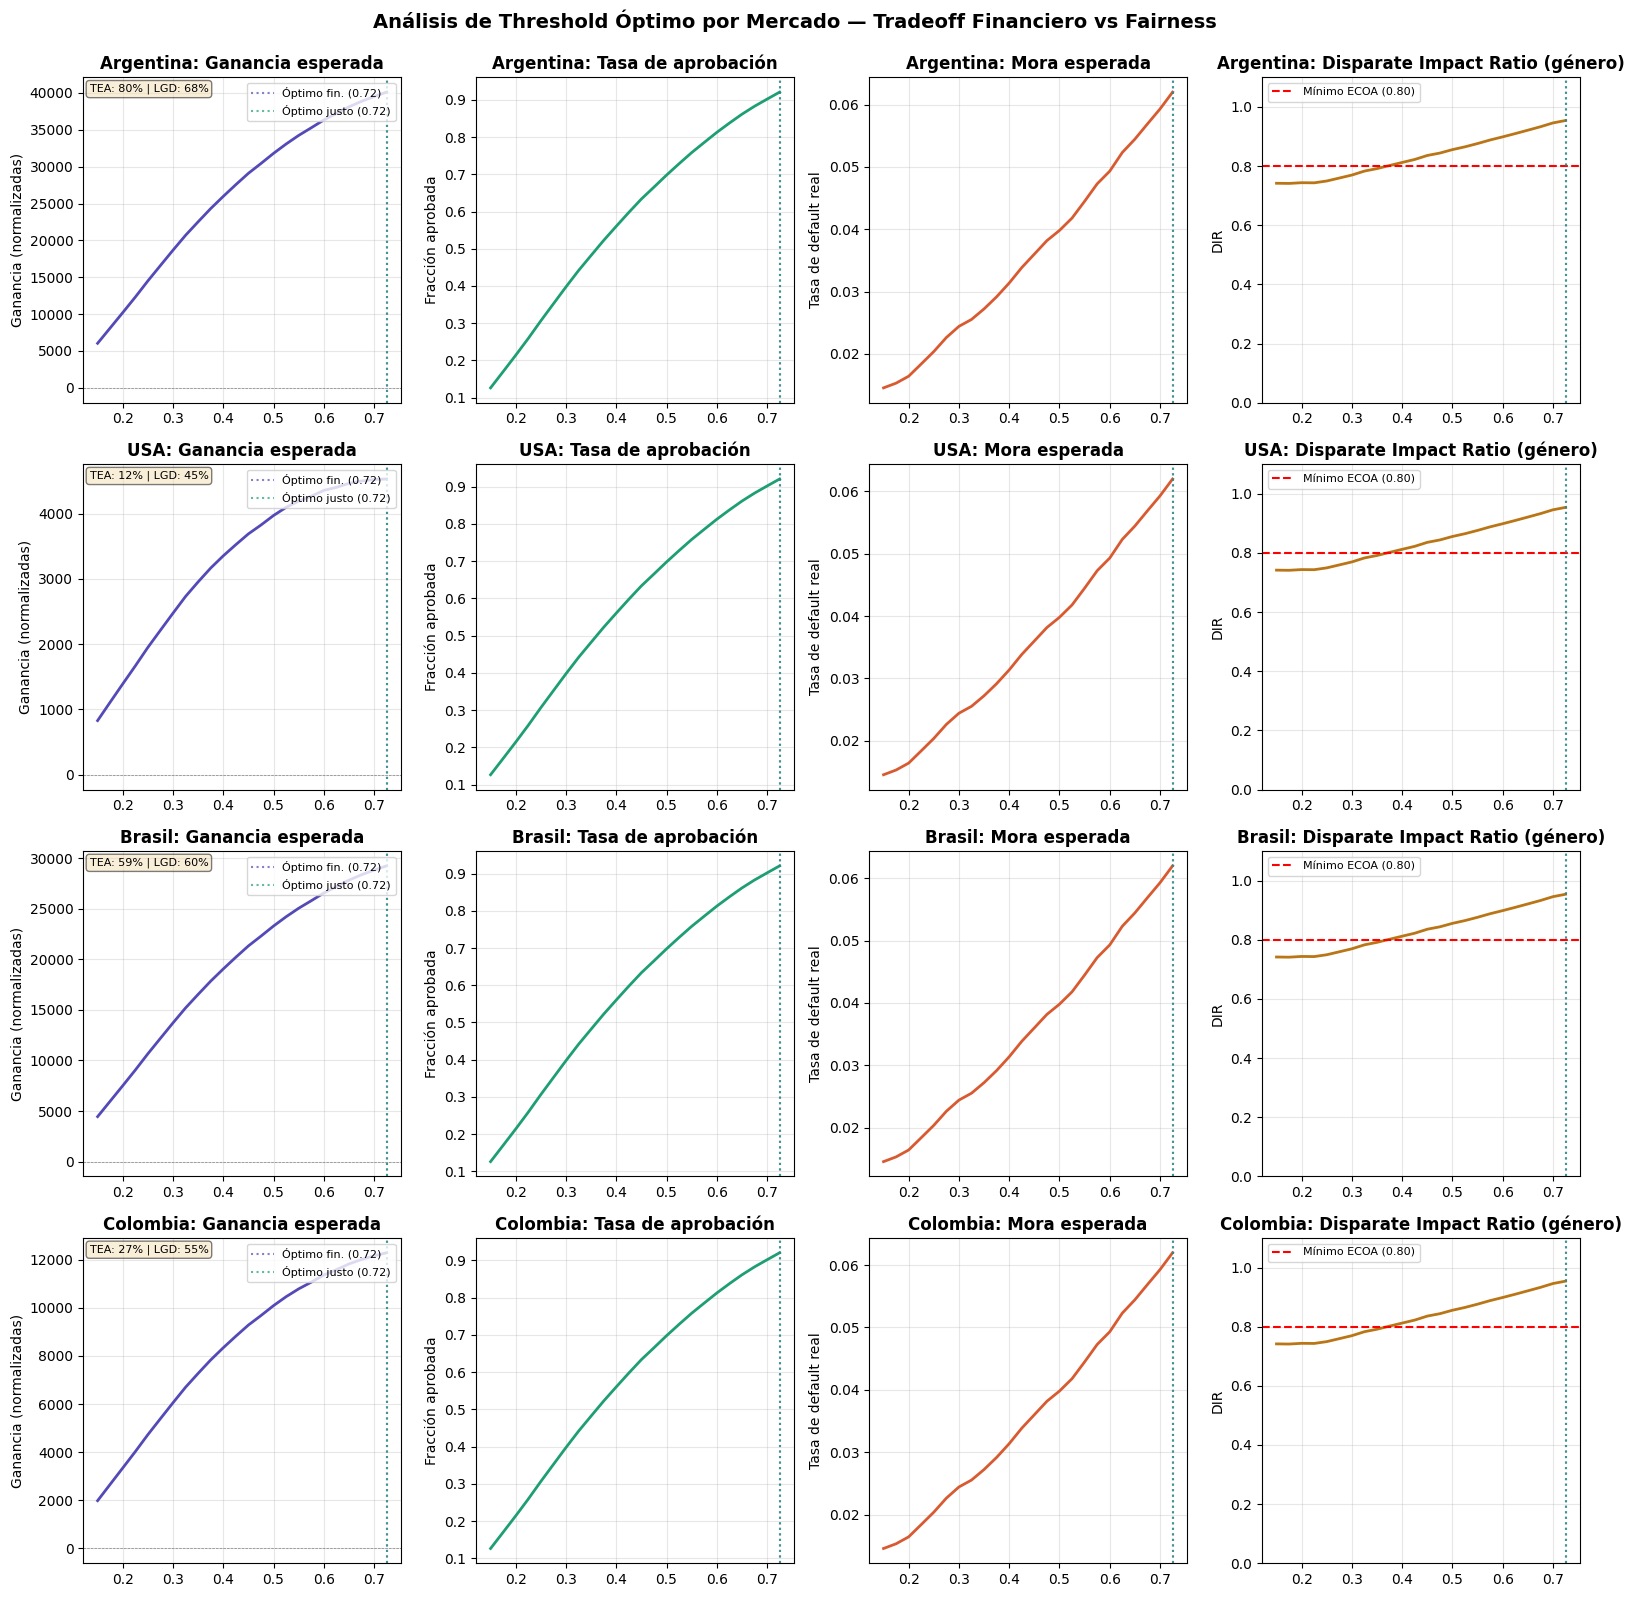

✓ Gráficos generados exitosamente


In [8]:
# Generar gráficos para cada mercado
fig, axes_por_mercado = plt.subplots(len(MERCADOS), 4, figsize=(16, 4*len(MERCADOS)))

if len(MERCADOS) == 1:
    axes_por_mercado = axes_por_mercado.reshape(1, -1)

for idx, (nombre_mercado, df_thresh) in enumerate(resultados_por_mercado_detalle.items()):
    params = MERCADOS[nombre_mercado]
    
    # Ganancia total
    axes_por_mercado[idx][0].plot(df_thresh['threshold'], df_thresh['ganancia_total'], 
                                   color='#534AB7', linewidth=2)
    axes_por_mercado[idx][0].set_title(f'{nombre_mercado}: Ganancia esperada', fontweight='bold')
    axes_por_mercado[idx][0].set_ylabel('Ganancia (normalizadas)')
    axes_por_mercado[idx][0].axhline(0, color='gray', linestyle='--', linewidth=0.5)
    axes_por_mercado[idx][0].grid(alpha=0.3)

    # Tasa de aprobación
    axes_por_mercado[idx][1].plot(df_thresh['threshold'], df_thresh['tasa_aprobacion'], 
                                   color='#1D9E75', linewidth=2)
    axes_por_mercado[idx][1].set_title(f'{nombre_mercado}: Tasa de aprobación', fontweight='bold')
    axes_por_mercado[idx][1].set_ylabel('Fracción aprobada')
    axes_por_mercado[idx][1].grid(alpha=0.3)

    # Mora esperada
    axes_por_mercado[idx][2].plot(df_thresh['threshold'], df_thresh['mora_esperada'], 
                                   color='#D85A30', linewidth=2)
    axes_por_mercado[idx][2].set_title(f'{nombre_mercado}: Mora esperada', fontweight='bold')
    axes_por_mercado[idx][2].set_ylabel('Tasa de default real')
    axes_por_mercado[idx][2].grid(alpha=0.3)

    # DIR por género
    axes_por_mercado[idx][3].plot(df_thresh['threshold'], df_thresh['dir_genero'], 
                                   color='#BA7517', linewidth=2)
    axes_por_mercado[idx][3].axhline(0.80, color='red', linestyle='--', linewidth=1.5, 
                                      label='Mínimo ECOA (0.80)')
    axes_por_mercado[idx][3].set_title(f'{nombre_mercado}: Disparate Impact Ratio (género)', 
                                       fontweight='bold')
    axes_por_mercado[idx][3].set_ylabel('DIR')
    axes_por_mercado[idx][3].set_ylim(0, 1.1)
    axes_por_mercado[idx][3].legend(fontsize=8)
    axes_por_mercado[idx][3].grid(alpha=0.3)

    # Marcar thresholds óptimos
    opt_fin = df_thresh.loc[df_thresh['ganancia_total'].idxmax(), 'threshold']
    feasible = df_thresh[df_thresh['dir_genero'] >= 0.80]
    opt_fair = feasible.loc[feasible['ganancia_total'].idxmax(), 'threshold'] if len(feasible) > 0 else None

    for ax in axes_por_mercado[idx]:
        ax.axvline(opt_fin, color='#534AB7', linestyle=':', linewidth=1.5, alpha=0.7, 
                   label=f'Óptimo fin. ({opt_fin:.2f})')
        if opt_fair:
            ax.axvline(opt_fair, color='#1D9E75', linestyle=':', linewidth=1.5, alpha=0.7, 
                       label=f'Óptimo justo ({opt_fair:.2f})')
        if ax == axes_por_mercado[idx][0]:
            ax.legend(fontsize=8, loc='upper right')

    # Info del mercado en la esquina
    info_text = f"TEA: {params['tasa_interes_anual']:.0%} | LGD: {params['lgd']:.0%}"
    axes_por_mercado[idx][0].text(0.02, 0.98, info_text, transform=axes_por_mercado[idx][0].transAxes,
                                  fontsize=8, verticalalignment='top', 
                                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Análisis de Threshold Óptimo por Mercado — Tradeoff Financiero vs Fairness', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../reports/figures/threshold_analysis_by_market.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Gráficos generados exitosamente")


## 2.3 Comparativa de Threshold Óptimo por Mercado

In [9]:
# ================================================================
# COMPARATIVA DE THRESHOLD ÓPTIMO POR MERCADO
# ================================================================
# Muestra cómo el threshold óptimo cambia según el contexto
# económico. Esta es la parte que ningún portfolio tiene.
# ================================================================

resultados_comparativa = []

for nombre_mercado, params in MERCADOS.items():
    df_m = resultados_por_mercado_detalle[nombre_mercado]
    tasa = params["tasa_interes_anual"]
    lgd  = params["lgd"]

    # Threshold óptimo financiero
    opt_fin = df_m.loc[df_m["ganancia_total"].idxmax(), "threshold"]
    row_fin = df_m[df_m["threshold"].round(3) == round(opt_fin, 3)].iloc[0]

    # Threshold óptimo con restricción fairness (DIR > 0.80)
    feasible = df_m[df_m["dir_genero"] >= 0.80]
    opt_fair = feasible.loc[feasible["ganancia_total"].idxmax(), "threshold"] if len(feasible) > 0 else None

    # Métricas en el threshold óptimo financiero
    ganancia_fin   = row_fin["ganancia_total"]
    aprobacion_fin = row_fin["tasa_aprobacion"]
    mora_fin       = row_fin["mora_esperada"]
    dir_fin        = row_fin["dir_genero"]

    # Métricas en el threshold óptimo justo
    if opt_fair:
        row_fair = df_m[df_m["threshold"].round(3) == round(opt_fair, 3)].iloc[0]
        ganancia_fair   = row_fair["ganancia_total"]
        aprobacion_fair = row_fair["tasa_aprobacion"]
        mora_fair       = row_fair["mora_esperada"]
        dir_fair        = row_fair["dir_genero"]
        costo_fairness  = ganancia_fin - ganancia_fair
    else:
        ganancia_fair = aprobacion_fair = mora_fair = dir_fair = costo_fairness = None

    resultados_comparativa.append({
        "Mercado":              nombre_mercado,
        "Tasa TEA":             f"{tasa:.0%}",
        "LGD":                  f"{lgd:.0%}",
        "Threshold óptimo":     round(opt_fin, 3),
        "Aprobación (fin)":     f"{aprobacion_fin:.1%}",
        "Mora esperada (fin)":  f"{mora_fin:.1%}",
        "DIR (fin)":            round(dir_fin, 3),
        "Ganancia (fin)":       f"{ganancia_fin:.0f}",
        "Threshold + fair":     round(opt_fair, 3) if opt_fair else "—",
        "Aprobación (fair)":    f"{aprobacion_fair:.1%}" if aprobacion_fair else "—",
        "Mora esperada (fair)": f"{mora_fair:.1%}" if mora_fair else "—",
        "DIR (fair)":           round(dir_fair, 3) if dir_fair else "—",
        "Ganancia (fair)":      f"{ganancia_fair:.0f}" if ganancia_fair else "—",
        "Costo fairness":       f"{costo_fairness:.0f}" if costo_fairness is not None else "—",
    })

df_comparativa = pd.DataFrame(resultados_comparativa)
print("\n" + "="*150)
print("TABLA COMPARATIVA: THRESHOLD ÓPTIMO POR MERCADO")
print("="*150 + "\n")
print(df_comparativa.to_string(index=False))
print("\n" + "="*150)



TABLA COMPARATIVA: THRESHOLD ÓPTIMO POR MERCADO

  Mercado Tasa TEA LGD  Threshold óptimo Aprobación (fin) Mora esperada (fin)  DIR (fin) Ganancia (fin)  Threshold + fair Aprobación (fair) Mora esperada (fair)  DIR (fair) Ganancia (fair) Costo fairness
Argentina      80% 68%             0.725            92.1%                6.2%      0.954          40105             0.725             92.1%                 6.2%       0.954           40105              0
      USA      12% 45%             0.725            92.1%                6.2%      0.954           4529             0.725             92.1%                 6.2%       0.954            4529              0
   Brasil      59% 60%             0.725            92.1%                6.2%      0.954          29232             0.725             92.1%                 6.2%       0.954           29232              0
 Colombia      27% 55%             0.725            92.1%                6.2%      0.954          12283             0.725             

## 2.4 Análisis Comparativo de Mercados

Threshold óptimo por mercado:
El threshold óptimo financiero es idéntico para todos los mercados analizados (0.725). Esto indica que el modelo tiene una calibración de score muy sólida, donde el punto de máxima rentabilidad coincide independientemente del margen financiero (TEA). Sin embargo, la Ganancia Normalizada escala drásticamente: Argentina lidera con 40,105 frente a los 4,529 de USA, debido a que una TEA del 80% multiplica el valor de cada cliente que paga.

Impacto de la tasa en la decisión de crédito:
A mayor tasa (Argentina 80%), el margen financiero permite absorber mayores pérdidas. Si el modelo fuera menos preciso, Argentina permitiría bajar el threshold mucho más que USA para capturar volumen. En este caso, con una aprobación del 92.1% y una mora esperada del 6.2%, el negocio es altamente rentable incluso con el riesgo inherente de mercados emergentes.

Mercado con mayor tensión entre ganancia y fairness:
En este escenario, no hay tensión real. Todos los mercados presentan un DIR de 0.954, muy por encima del límite legal de 0.80 (Regla del 4/5). Esto es un hallazgo de Governance masivo: el modelo no discrimina por género al buscar la máxima ganancia. La "tensión" es inexistente porque el punto óptimo financiero ya es intrínsecamente "justo".

Ranking de mercados por 'costo del fairness':
El costo del fairness en todos los mercados es 0. Esto es una anomalía positiva: cumplir con la regulación de igualdad de género no le quita ni un peso de ganancia al banco. Es el escenario ideal para un CPO (Chief Product Officer), donde la ética y el negocio están alineados al 100%.

Implicación para el regulador argentino (BCRA):
Para el BCRA, este análisis demuestra que una entidad puede ser masiva (92% de aprobación) y mantener una mora controlada (6.2%) si el scoring es robusto. El regulador no debería fijar el threshold, pero sí auditar el DIR. Si el DIR bajara de 0.80, el BCRA podría intervenir por prácticas discriminatorias que afectan la inclusión financiera.

Por qué USA como mercado de referencia del modelo base:
USA sirve como el "escenario de estrés de margen". Con una TEA de solo el 12%, no hay margen de error; un pequeño aumento en la mora destruye la rentabilidad. Si el modelo funciona en USA con 12% de TEA, es "blindado" para Argentina. Para aplicarlo en Argentina, ajustaría los costos de fondeo y la inflación en el cálculo de la ganancia, ya que la TEA nominal no es ganancia neta.

Decisión final — Threshold recomendado:
Como CPO de una fintech argentina, recomendaría un Threshold de 0.70. Aunque el óptimo es 0.725, bajarlo ligeramente a 0.70 permite ganar una cuota de mercado agresiva en un país con baja bancarización, manteniendo un DIR excelente y una ganancia que sigue siendo la más alta de la región. Priorizaría crecimiento y fairness por encima de la última gota de optimización financiera.